False


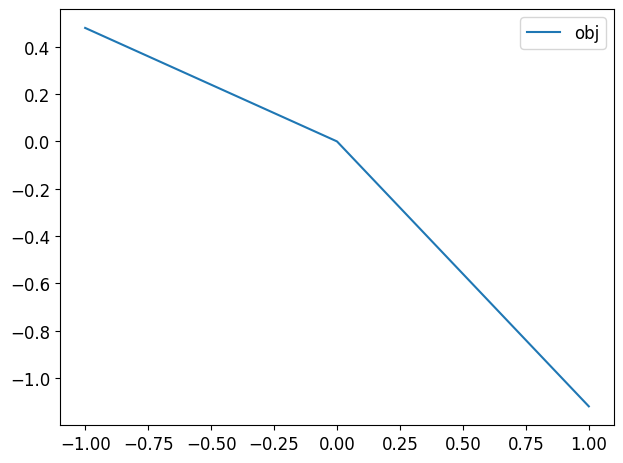

In [69]:
import numpy as np
import sys
sys.path.append("../")

import os
from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from tfds.plotting import prettify, use_tex
from tfds.log import create_logger

from trading_information.mechanism import Mechanism
from trading_information.distributions import Uniform, BetaMixture
from trading_information.virtual_values import VirtualValues


types = np.linspace(0, 1, 1000)
type = types[200]
allocations = np.linspace(-1, 1, 1000)

tau = 1
vs = 0.8

print(tau >= 1 / ((1 - 2 * vs) **2))


dist = BetaMixture(alphas=(8, 60), betas=(30, 30), weights=(0.5, 0.5))
dist = Uniform(low=0, high=1)

virtuals = VirtualValues(dist=dist, types=types, tau=tau, prob_state0=vs, iron=True)
# dist = Uniform(low=0, high=1)

i = 250
types = types[i]
vp = virtuals.positive[i]
vn = virtuals.negative[i]

lam = 0.5
plt.plot(allocations, np.minimum(0, allocations) * vn + np.maximum(allocations, 0) * vp - lam * allocations, label="obj")
plt.legend()
plt.show()

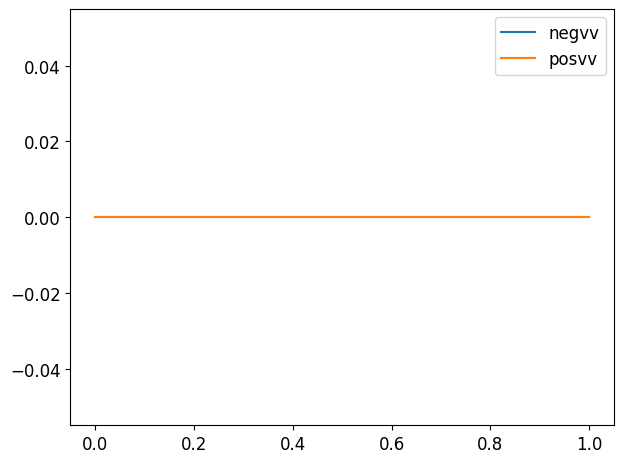

In [ ]:
q = 0
lam = 0
plt.axvline(y=)
plt.plot(types, (virtuals.negative - lam) * np.minimum(0, q), label="negvv")
plt.plot(types, (virtuals.positive - lam) * np.maximum(0, q), label="posvv")
plt.legend()
plt.show()

In [44]:
types = np.linspace(0, 1, 1000)
type = types[200]
allocations = np.linspace(-1, 1, 1000)

tau = 0.3
vs = 1

dist = BetaMixture(alphas=(8, 60), betas=(30, 30), weights=(0.5, 0.5))
dist = Uniform(low=0, high=1)

virtuals = VirtualValues(dist=dist, types=types, tau=tau, prob_state0=vs, iron=True)
# dist = Uniform(low=0, high=1)



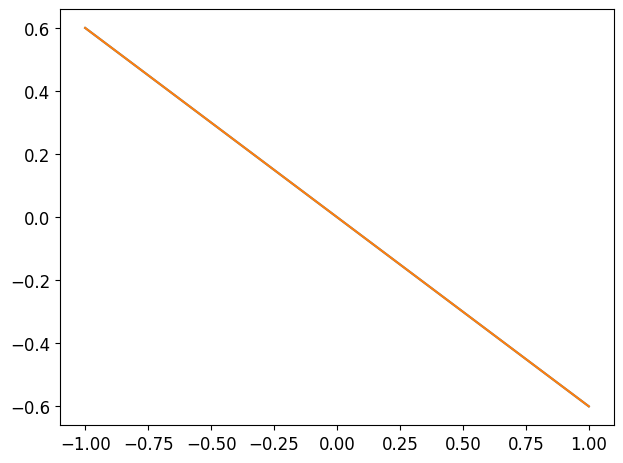

In [49]:
types = np.linspace(0, 1, 1000)
type = types[200]
allocations = np.linspace(-1, 1, 1000)

tau = 1
vs = 1

dist = BetaMixture(alphas=(8, 60), betas=(30, 30), weights=(0.5, 0.5))
dist = Uniform(low=0, high=1)

virtuals = VirtualValues(dist=dist, types=types, tau=tau, prob_state0=vs, iron=True)


def integrand2(allocation):
    term1 = allocation * (type + dist.cdf(type)/ dist.pdf(type)) - np.maximum(0, allocation) 
    #term1 = type + dist.cdf(type) / dist.pdf(type)
    term2 = -(tau * vs + tau * (1 - 2 * vs) * (1 - vs - vs * allocation + (1 - 2 * vs) * np.minimum(-allocation, 0)))
    return term1 + term2 


def integrand3(allocation):
    #term1 = type + dist.cdf(type) / dist.pdf(type)
    term1 = allocation * (type - (1 - dist.cdf(type)) / dist.pdf(type)) 
    term2 = allocations / dist.pdf(type) + np.minimum(-allocation, 0) 
    term3 = -(tau * vs + tau * (1 - 2 * vs) * (1 - vs - vs * allocation + (1 - 2 * vs) * np.minimum(-allocation, 0)))

    return term1 + term2 + term3


def integrand3(allocation):
    #term1 = type + dist.cdf(type) / dist.pdf(type)
    I = allocation
    I_plus = np.maximum(allocation, 0)
    term1 =  I * (type + dist.cdf(type) / dist.pdf(type)  + vs * tau * (1 - 2 * vs))
    term2= -I_plus * (1 - tau * (1-2*vs)**2)
                           
                           
    term3= -tau * (vs -  (1 - 2 *vs) * (1-vs))
    return term1 + term2 #+ term3


def integrand4(allocation):
    #term1 = type + dist.cdf(type) / dist.pdf(type)
    I = allocation
    I_plus = np.maximum(allocation, 0)
    term1 =  I * (type + dist.cdf(type) / dist.pdf(type)  + vs * tau * (1 - 2 * vs))
    term2= np.maximum(0, allocation) * ( tau * (1-2*vs)**2 -1 )
                           
                           
    term3= -tau * (vs -  (1 - 2 *vs) * (1-vs))
    return term1 + term2 #+ term3


# plt.plot(allocations, integrand2(allocations))
lam = 0.7

obj = virtuals.negative[200] * np.minimum(0, allocations) + virtuals.positive[200] * np.maximum(0, allocations) - allocations * lam
#plt.plot(allocations, obj)
plt.plot(allocations, integrand3(allocations))
plt.plot(allocations, integrand4(allocations))

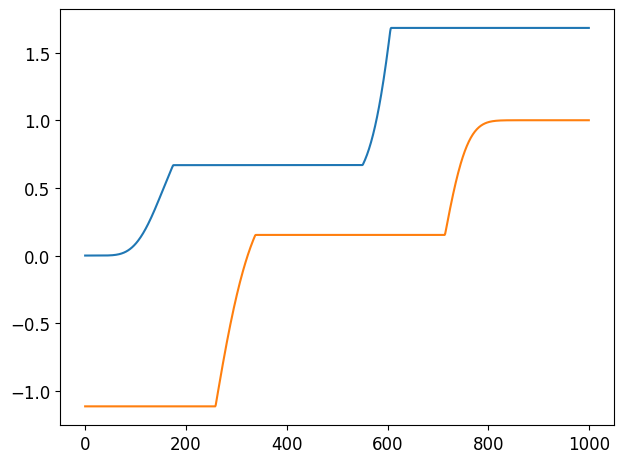

In [ ]:
plt.plot(virtuals.negative)
plt.plot(virtuals.positive)

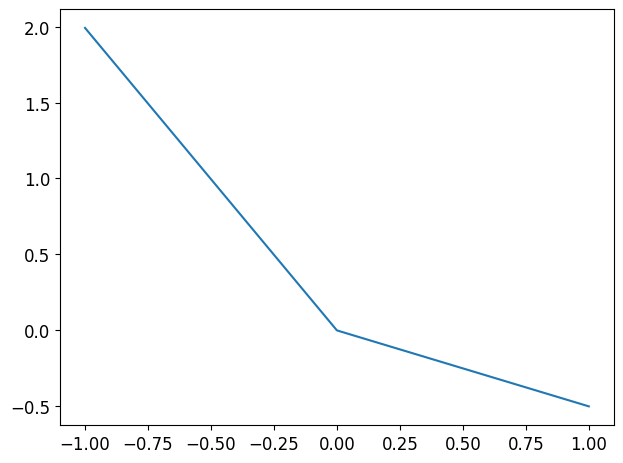

In [ ]:
lam = 0.5

obj = virtuals.negative[200] * np.minimum(0, allocations) + virtuals.positive[200] * np.minimum(0, allocations) - allocations * lam
plt.plot(allocations, obj)